<a href="https://colab.research.google.com/github/IoTLab403/ex1/blob/main/Copy_of_TIRUPATI_IOT_SAMHA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
class SAMHA(nn.Module):
    def __init__(self, in_channels):
        super(SAMHA, self).__init__()

        self.cnn = MultiScaleCNN(in_channels=in_channels)

        self.bigru = nn.GRU(
            input_size=96,
            hidden_size=128,
            batch_first=True,
            bidirectional=True
        )

        # Simple attention gate example
        self.attention = nn.Linear(256, 1)

        self.fc = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)  # Regression target
        )

    def forward(self, x):
        # x = (batch, channels, time)
        cnn_out = self.cnn(x)                     # (batch, 96, time)
        cnn_out = cnn_out.permute(0, 2, 1)        # (batch, time, 96)

        gru_out, _ = self.bigru(cnn_out)          # (batch, time, 256)

        # Attention weights
        att = torch.softmax(self.attention(gru_out), dim=1)
        context = (gru_out * att).sum(dim=1)      # (batch, 256)

        out = self.fc(context)
        return out


NameError: name 'nn' is not defined

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# -----------------------------
# 1. Create hourly timestamps for TODAY
# -----------------------------
today = datetime.now().date()
timestamps = [datetime.combine(today, datetime.min.time()) + timedelta(hours=i) for i in range(24)]

# -----------------------------
# 2. Generate realistic Tirupati-like data
# -----------------------------
np.random.seed(42)

temperature = np.random.uniform(24, 38, 24).round(1)      # °C
humidity    = np.random.uniform(35, 85, 24).round(1)      # %
MQ135       = np.random.uniform(80, 260, 24).round(0)     # AQI-like index
PM25        = np.random.uniform(20, 180, 24).round(1)     # µg/m³
PM10        = np.random.uniform(40, 300, 24).round(1)     # µg/m³
CO          = np.random.uniform(0.4, 3.5, 24).round(2)    # ppm
SO2         = np.random.uniform(2, 25, 24).round(1)       # ppb
NO2         = np.random.uniform(5, 90, 24).round(1)       # ppb

# -----------------------------
# 3. Create AQI target (simple weighted formula)
# -----------------------------
AQI = (
    0.4 * PM25 +
    0.2 * PM10 +
    0.2 * MQ135 +
    5 * CO +
    0.3 * NO2 +
    np.random.normal(0, 10, 24)
).round(0)

# -----------------------------
# 4. AQI Category Function
# -----------------------------
def air_quality_label(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"

air_quality = [air_quality_label(a) for a in AQI]

# -----------------------------
# 5. Notes column
# -----------------------------
notes = [
    "Morning traffic" if 7 <= t.hour <= 10 else
    "Evening traffic" if 17 <= t.hour <= 21 else
    "Normal conditions"
    for t in timestamps
]

# -----------------------------
# 6. Build DataFrame
# -----------------------------
df = pd.DataFrame({
    "timestamp": timestamps,
    "temperature": temperature,
    "humidity": humidity,
    "MQ135": MQ135,
    "PM25": PM25,
    "PM10": PM10,
    "CO": CO,
    "SO2": SO2,
    "NO2": NO2,
    "target": AQI,
    "air_quality": air_quality,
    "notes": notes
})

# -----------------------------
# 7. Save CSV
# -----------------------------
df.to_csv("tirupati_iot.csv", index=False)

print("✅ tirupati_iot.csv created successfully!")
print(df.head())


✅ tirupati_iot.csv created successfully!
            timestamp  temperature  humidity  MQ135   PM25   PM10    CO   SO2  \
0 2025-12-29 00:00:00         29.2      57.8  178.0   20.9  175.9  2.90   8.6   
1 2025-12-29 01:00:00         37.3      74.3  113.0  150.5  151.2  3.18   2.8   
2 2025-12-29 02:00:00         34.2      45.0  255.0  133.1   46.6  1.39  16.0   
3 2025-12-29 03:00:00         32.4      60.7  220.0  136.6   68.1  0.74  13.6   
4 2025-12-29 04:00:00         26.2      64.6  249.0  143.4   48.2  1.11   3.2   

    NO2  target   air_quality              notes  
0   8.5    99.0  Satisfactory  Normal conditions  
1  55.2   153.0      Moderate  Normal conditions  
2  62.6   127.0      Moderate  Normal conditions  
3   6.4   105.0      Moderate  Normal conditions  
4  48.5   142.0      Moderate  Normal conditions  


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# -----------------------------
# 1. Create timestamps every 5 minutes for TODAY
# -----------------------------
today = datetime.now().date()
start_time = datetime.combine(today, datetime.min.time())
timestamps = [start_time + timedelta(minutes=5*i) for i in range(288)]

# -----------------------------
# 2. Set random seed for reproducibility
# -----------------------------
np.random.seed(42)

# -----------------------------
# 3. Generate realistic Tirupati-like sensor data
# -----------------------------
temperature = np.random.uniform(24, 38, 288).round(1)      # °C
humidity    = np.random.uniform(35, 85, 288).round(1)      # %
MQ135       = np.random.uniform(80, 260, 288).round(0)     # gas index
PM25        = np.random.uniform(20, 180, 288).round(1)     # µg/m³
PM10        = np.random.uniform(40, 300, 288).round(1)     # µg/m³
CO          = np.random.uniform(0.4, 3.5, 288).round(2)    # ppm
SO2         = np.random.uniform(2, 25, 288).round(1)      # ppb
NO2         = np.random.uniform(5, 90, 288).round(1)      # ppb

# -----------------------------
# 4. Create AQI target (synthetic formula)
# -----------------------------
AQI = (
    0.4 * PM25 +
    0.2 * PM10 +
    0.2 * MQ135 +
    5.0 * CO +
    0.3 * NO2 +
    np.random.normal(0, 10, 288)
).round(0)

# -----------------------------
# 5. AQI category function
# -----------------------------
def air_quality_label(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"

air_quality = [air_quality_label(a) for a in AQI]

# -----------------------------
# 6. Notes column (time-aware)
# -----------------------------
notes = []
for t in timestamps:
    if 6 <= t.hour <= 10:
        notes.append("Morning traffic")
    elif 17 <= t.hour <= 21:
        notes.append("Evening traffic")
    else:
        notes.append("Normal conditions")

# -----------------------------
# 7. Build DataFrame
# -----------------------------
df = pd.DataFrame({
    "timestamp": timestamps,
    "temperature": temperature,
    "humidity": humidity,
    "MQ135": MQ135,
    "PM25": PM25,
    "PM10": PM10,
    "CO": CO,
    "SO2": SO2,
    "NO2": NO2,
    "target": AQI,
    "air_quality": air_quality,
    "notes": notes
})

# -----------------------------
# 8. Save CSV
# -----------------------------
df.to_csv("tirupati_iot.csv", index=False)

print("✅ tirupati_iot.csv created with 5-minute interval data!")
print("Total rows:", len(df))
print(df.head())


✅ tirupati_iot.csv created with 5-minute interval data!
Total rows: 288
            timestamp  temperature  humidity  MQ135   PM25   PM10    CO   SO2  \
0 2025-12-29 00:00:00         29.2      49.3  106.0   84.1  221.3  3.41  20.7   
1 2025-12-29 00:05:00         37.3      64.5  247.0  109.5  216.8  0.69  16.2   
2 2025-12-29 00:10:00         34.2      36.5  169.0   44.8  200.8  2.49   9.0   
3 2025-12-29 00:15:00         32.4      36.9  126.0   49.1  235.7  1.78  16.3   
4 2025-12-29 00:20:00         26.2      76.1  163.0  157.9   81.2  3.09  14.1   

    NO2  target air_quality              notes  
0  34.5   125.0    Moderate  Normal conditions  
1  81.5   171.0    Moderate  Normal conditions  
2   6.9   109.0    Moderate  Normal conditions  
3  61.4   112.0    Moderate  Normal conditions  
4  86.9   150.0    Moderate  Normal conditions  


In [ ]:
# ============================================
# evaluate_models.py
# ============================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# -----------------------------
# CONFIG
# -----------------------------
CSV_PATH = "tirupati_iot.csv"
WINDOW = 24
BATCH_SIZE = 32
EPOCHS = 5
AQI_THRESHOLD = 100

# -----------------------------
# DATASET
# -----------------------------
class IoTDataset(Dataset):
    def __init__(self, csv, window):
        df = pd.read_csv(csv)

        self.X = df[
            ["temperature","humidity","MQ135",
             "PM25","PM10","CO","SO2","NO2"]
        ].values

        self.y = df["target"].values
        self.window = window

    def __len__(self):
        return len(self.X) - self.window

    def __getitem__(self, idx):
        x = self.X[idx:idx+self.window]
        y = self.y[idx+self.window]
        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32)
        )

# -----------------------------
# MODELS
# -----------------------------
class Seq2Point(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(8, 32, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x.permute(0,2,1))


class Seq2Seq(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(8, 64, batch_first=True)
        self.fc = nn.Linear(64,1)

    def forward(self, x):
        out,_ = self.lstm(x)
        return self.fc(out[:,-1,:])


class WindowGRU(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(8, 64, batch_first=True)
        self.fc = nn.Linear(64,1)

    def forward(self, x):
        out,_ = self.gru(x)
        return self.fc(out[:,-1,:])


class DAE(nn.Module):
    def __init__(self, window):
        super().__init__()
        self.encoder = nn.Linear(8*window, 64)
        self.reg = nn.Linear(64,1)

    def forward(self, x):
        z = torch.relu(self.encoder(x.view(x.size(0), -1)))
        return self.reg(z)


class SAMHA(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Conv1d(8, 64, 3, padding=1)
        self.gru = nn.GRU(64, 64, batch_first=True, bidirectional=True)
        self.att = nn.Linear(128,1)
        self.fc = nn.Linear(128,1)

    def forward(self, x):
        x = torch.relu(self.cnn(x.permute(0,2,1)))
        x = x.permute(0,2,1)
        h,_ = self.gru(x)
        w = torch.softmax(self.att(h), dim=1)
        c = (h * w).sum(dim=1)
        return self.fc(c)

# -----------------------------
# TRAIN FUNCTION
# -----------------------------
def train_model(model, loader, epochs):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    model.train()
    for _ in range(epochs):
        for x,y in loader:
            optimizer.zero_grad()
            loss = loss_fn(model(x).squeeze(), y)
            loss.backward()
            optimizer.step()

# -----------------------------
# EVALUATION FUNCTION
# -----------------------------

def evaluate_model(model, loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x,y in loader:
            pred = model(x).squeeze()
            y_true.extend(y.numpy())
            y_pred.extend(pred.numpy())

    # Regression
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    # Classification
    y_true_cls = (np.array(y_true) > AQI_THRESHOLD).astype(int)
    y_pred_cls = (np.array(y_pred) > AQI_THRESHOLD).astype(int)

    cm = confusion_matrix(y_true_cls, y_pred_cls, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()

    acc = accuracy_score(y_true_cls, y_pred_cls)
    prec = precision_score(y_true_cls, y_pred_cls, zero_division=0)
    rec = recall_score(y_true_cls, y_pred_cls, zero_division=0)
    f1 = f1_score(y_true_cls, y_pred_cls, zero_division=0)

    return [mae, rmse, tp, tn, fp, fn, acc, prec, rec, f1]

# -----------------------------
# MAIN
# -----------------------------
if __name__ == "__main__":

    dataset = IoTDataset(CSV_PATH, WINDOW)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

    models = {
        "Seq2Point": Seq2Point(),
        "Seq2Seq": Seq2Seq(),
        "DAE": DAE(WINDOW),
        "WindowGRU": WindowGRU(),
        "SAMHA": SAMHA()
    }

    results = []

    for name, model in models.items():
        print(f"\nTraining {name}...")
        train_model(model, loader, EPOCHS)
        metrics = evaluate_model(model, loader)
        results.append([name] + metrics)

    df_results = pd.DataFrame(
        results,
        columns=[
            "Model","MAE","RMSE","TP","TN","FP","FN",
            "Accuracy","Precision","Recall","F1"
        ]
    )

    print("\n=== FINAL RESULTS ===")
    print(df_results)



Training Seq2Point...

Training Seq2Seq...

Training DAE...

Training WindowGRU...

Training SAMHA...

=== FINAL RESULTS ===
       Model         MAE        RMSE   TP  TN  FP   FN  Accuracy  Precision  \
0  Seq2Point   26.222339   32.736240  226   0  38    0  0.856061   0.856061   
1    Seq2Seq  128.275168  131.598224    0  38   0  226  0.143939   0.000000   
2        DAE   24.453382   29.831761  226   0  38    0  0.856061   0.856061   
3  WindowGRU  127.525450  130.867469    0  38   0  226  0.143939   0.000000   
4      SAMHA  123.344021  126.796606    0  38   0  226  0.143939   0.000000   

   Recall        F1  
0     1.0  0.922449  
1     0.0  0.000000  
2     1.0  0.922449  
3     0.0  0.000000  
4     0.0  0.000000  


In [ ]:
# ============================================================
# SAMHA FULL PIPELINE – SINGLE FILE (GOOGLE COLAB READY)
# ============================================================

# ----------------------------
# 1. MOUNT GOOGLE DRIVE
# ----------------------------
from google.colab import drive
drive.mount('/content/drive')

# ----------------------------
# 2. IMPORTS
# ----------------------------
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ----------------------------
# 3. PATHS & CONFIG
# ----------------------------
CSV_PATH = "/content/drive/MyDrive/SAMHA_PROJECT/tirupati_iot.csv"
SAVE_DIR = "/content/drive/MyDrive/SAMHA_PROJECT/models/"
os.makedirs(SAVE_DIR, exist_ok=True)

WINDOW = 24
BATCH_SIZE = 32
EPOCHS = 5
AQI_THRESHOLD = 100

# ----------------------------
# 4. DATASET
# ----------------------------
class IoTDataset(Dataset):
    def __init__(self, csv, window):
        df = pd.read_csv(csv)

        self.X = df[
            ["temperature","humidity","MQ135",
             "PM25","PM10","CO","SO2","NO2"]
        ].values

        self.y = df["target"].values
        self.window = window

    def __len__(self):
        return len(self.X) - self.window

    def __getitem__(self, idx):
        x = self.X[idx:idx+self.window]
        y = self.y[idx+self.window]
        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32)
        )

# ----------------------------
# 5. MODELS
# ----------------------------
class Seq2Point(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(8, 32, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x.permute(0,2,1))


class Seq2Seq(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(8, 64, batch_first=True)
        self.fc = nn.Linear(64,1)

    def forward(self, x):
        out,_ = self.lstm(x)
        return self.fc(out[:,-1,:])


class WindowGRU(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(8, 64, batch_first=True)
        self.fc = nn.Linear(64,1)

    def forward(self, x):
        out,_ = self.gru(x)
        return self.fc(out[:,-1,:])


class DAE(nn.Module):
    def __init__(self, window):
        super().__init__()
        self.encoder = nn.Linear(8*window, 64)
        self.reg = nn.Linear(64,1)

    def forward(self, x):
        z = torch.relu(self.encoder(x.view(x.size(0), -1)))
        return self.reg(z)


class SAMHA(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Conv1d(8, 64, 3, padding=1)
        self.gru = nn.GRU(64, 64, batch_first=True, bidirectional=True)
        self.att = nn.Linear(128,1)
        self.fc = nn.Linear(128,1)

    def forward(self, x):
        x = torch.relu(self.cnn(x.permute(0,2,1)))
        x = x.permute(0,2,1)
        h,_ = self.gru(x)
        w = torch.softmax(self.att(h), dim=1)
        c = (h * w).sum(dim=1)
        return self.fc(c)

# ----------------------------
# 6. TRAIN FUNCTION
# ----------------------------
def train_model(model, loader, epochs):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    model.train()

    for _ in range(epochs):
        for x,y in loader:
            optimizer.zero_grad()
            loss = loss_fn(model(x).squeeze(), y)
            loss.backward()
            optimizer.step()

# ----------------------------
# 7. EVALUATION FUNCTION
# ----------------------------
def evaluate_model(model, loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x,y in loader:
            pred = model(x).squeeze()
            y_true.extend(y.numpy())
            y_pred.extend(pred.numpy())

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    y_true_cls = (np.array(y_true) > AQI_THRESHOLD).astype(int)
    y_pred_cls = (np.array(y_pred) > AQI_THRESHOLD).astype(int)

    cm = confusion_matrix(y_true_cls, y_pred_cls, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()

    return {
        "MAE": mae,
        "RMSE": rmse,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "Accuracy": accuracy_score(y_true_cls, y_pred_cls),
        "Precision": precision_score(y_true_cls, y_pred_cls, zero_division=0),
        "Recall": recall_score(y_true_cls, y_pred_cls, zero_division=0),
        "F1": f1_score(y_true_cls, y_pred_cls, zero_division=0)
    }

# ----------------------------
# 8. LOAD DATA
# ----------------------------
dataset = IoTDataset(CSV_PATH, WINDOW)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# ----------------------------
# 9. TRAIN, EVALUATE & SAVE
# ----------------------------
models = {
    "Seq2Point": Seq2Point(),
    "Seq2Seq": Seq2Seq(),
    "DAE": DAE(WINDOW),
    "WindowGRU": WindowGRU(),
    "SAMHA": SAMHA()
}

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    train_model(model, loader, EPOCHS)

    metrics = evaluate_model(model, loader)
    results.append([name] + list(metrics.values()))

    torch.save(model.state_dict(), SAVE_DIR + f"{name.lower()}.pth")

# ----------------------------
# 10. SAVE RESULTS
# ----------------------------
df_results = pd.DataFrame(
    results,
    columns=["Model","MAE","RMSE","TP","TN","FP","FN",
             "Accuracy","Precision","Recall","F1"]
)

RESULTS_PATH = SAVE_DIR + "evaluation_results.csv"
df_results.to_csv(RESULTS_PATH, index=False)

print("\n=== FINAL RESULTS ===")
print(df_results)

# ----------------------------
# 11. LOAD SAMHA & PREDICT (EXAMPLE)
# ----------------------------
samha = SAMHA()
samha.load_state_dict(torch.load(SAVE_DIR + "samha.pth"))
samha.eval()

df = pd.read_csv(CSV_PATH)
sample = df[
    ["temperature","humidity","MQ135",
     "PM25","PM10","CO","SO2","NO2"]
].values[:WINDOW]

x = torch.tensor(sample, dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    pred_aqi = samha(x).item()

print("\nExample Prediction (SAMHA)")
print("Predicted AQI:", pred_aqi)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Training Seq2Point...

Training Seq2Seq...

Training DAE...

Training WindowGRU...

Training SAMHA...

=== FINAL RESULTS ===
       Model         MAE        RMSE   TP  TN  FP   FN  Accuracy  Precision  \
0  Seq2Point   30.778682   37.822244  226   0  38    0  0.856061   0.856061   
1    Seq2Seq  128.522575  131.840025    0  38   0  226  0.143939   0.000000   
2        DAE   24.994120   30.655354  226   0  38    0  0.856061   0.856061   
3  WindowGRU  127.418289  130.761525    0  38   0  226  0.143939   0.000000   
4      SAMHA  123.774439  127.215347    0  38   0  226  0.143939   0.000000   

   Recall        F1  
0     1.0  0.922449  
1     0.0  0.000000  
2     1.0  0.922449  
3     0.0  0.000000  
4     0.0  0.000000  

Example Prediction (SAMHA)
Predicted AQI: 8.036392211914062


In [1]:
# ============================================================
# RUN_ALL_MODELS_AND_PLOTS.py
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ----------------------------
# CONFIG
# ----------------------------
CSV_PATH = "tirupati_iot.csv"        # change if needed
MODEL_DIR = "./models"               # auto-created
WINDOW = 24
BATCH_SIZE = 64
EPOCHS = 5
AQI_THRESHOLD = 100

os.makedirs(MODEL_DIR, exist_ok=True)

# ----------------------------
# DATASET
# ----------------------------
class IoTDataset(Dataset):
    def __init__(self, csv, window):
        df = pd.read_csv(csv)
        self.X = df[
            ["temperature","humidity","MQ135",
             "PM25","PM10","CO","SO2","NO2"]
        ].values
        self.y = df["target"].values
        self.window = window

    def __len__(self):
        return len(self.X) - self.window

    def __getitem__(self, idx):
        x = self.X[idx:idx+self.window]
        y = self.y[idx+self.window]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# ----------------------------
# MODELS
# ----------------------------
class Seq2Point(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(8, 32, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x.permute(0,2,1))

class Seq2Seq(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(8, 64, batch_first=True)
        self.fc = nn.Linear(64,1)
    def forward(self, x):
        o,_ = self.lstm(x)
        return self.fc(o[:,-1,:])

class WindowGRU(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(8, 64, batch_first=True)
        self.fc = nn.Linear(64,1)
    def forward(self, x):
        o,_ = self.gru(x)
        return self.fc(o[:,-1,:])

class DAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Linear(8*WINDOW, 64)
        self.fc = nn.Linear(64,1)
    def forward(self, x):
        z = torch.relu(self.enc(x.view(x.size(0), -1)))
        return self.fc(z)

class SAMHA(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Conv1d(8, 64, 3, padding=1)
        self.gru = nn.GRU(64, 64, batch_first=True, bidirectional=True)
        self.att = nn.Linear(128,1)
        self.fc = nn.Linear(128,1)
    def forward(self, x):
        x = torch.relu(self.cnn(x.permute(0,2,1)))
        x = x.permute(0,2,1)
        h,_ = self.gru(x)
        w = torch.softmax(self.att(h), dim=1)
        return self.fc((h*w).sum(dim=1))

# ----------------------------
# TRAIN FUNCTION
# ----------------------------
def train_model(model, loader, epochs):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    model.train()
    for _ in range(epochs):
        for x,y in loader:
            opt.zero_grad()
            loss = loss_fn(model(x).squeeze(), y)
            loss.backward()
            opt.step()

# ----------------------------
# LOAD DATA
# ----------------------------
dataset = IoTDataset(CSV_PATH, WINDOW)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# ----------------------------
# INIT MODELS
# ----------------------------
models = {
    "Seq2Point": Seq2Point(),
    "Seq2Seq": Seq2Seq(),
    "DAE": DAE(),
    "WindowGRU": WindowGRU(),
    "SAMHA": SAMHA()
}

# ----------------------------
# AUTO TRAIN / LOAD MODELS
# ----------------------------
for name, model in models.items():
    path = f"{MODEL_DIR}/{name.lower()}.pth"
    if os.path.exists(path):
        print(f"Loading {name}")
        model.load_state_dict(torch.load(path))
    else:
        print(f"Training {name}")
        train_model(model, loader, EPOCHS)
        torch.save(model.state_dict(), path)
    model.eval()

# ----------------------------
# EVALUATE
# ----------------------------
metrics = {}
conf_mats = {}

for name, model in models.items():
    y_true, y_pred = [], []

    with torch.no_grad():
        for x,y in loader:
            p = model(x).squeeze().numpy()
            y_true.extend(y.numpy())
            y_pred.extend(p)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    y_true_c = (y_true > AQI_THRESHOLD).astype(int)
    y_pred_c = (y_pred > AQI_THRESHOLD).astype(int)

    cm = confusion_matrix(y_true_c, y_pred_c, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()

    metrics[name] = {
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "Accuracy": accuracy_score(y_true_c, y_pred_c),
        "Precision": precision_score(y_true_c, y_pred_c, zero_division=0),
        "Recall": recall_score(y_true_c, y_pred_c, zero_division=0),
        "F1": f1_score(y_true_c, y_pred_c, zero_division=0)
    }
    conf_mats[name] = cm

# ----------------------------
# PLOT METRIC BARS (SIMILAR TO YOUR IMAGE)
# ----------------------------
metric_names = ["TP","TN","FP","FN","Accuracy","Precision","Recall","F1"]
model_names = list(models.keys())

fig, axes = plt.subplots(len(metric_names), 1, figsize=(14, 22))
fig.suptitle("Seq2Point vs Seq2Seq vs DAE vs WindowGRU vs SAMHA", fontsize=16)

for i, m in enumerate(metric_names):
    vals = [metrics[k][m] for k in model_names]
    axes[i].bar(model_names, vals)
    axes[i].set_ylabel(m)
    axes[i].grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

# ----------------------------
# PLOT CONFUSION MATRICES
# ----------------------------
fig, axes = plt.subplots(1, len(model_names), figsize=(22,4))
fig.suptitle("Confusion Matrices", fontsize=16)

for ax, name in zip(axes, model_names):
    cm = conf_mats[name]
    ax.imshow(cm, cmap="Blues")
    ax.set_title(name)
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i,j], ha="center", va="center")

plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'tirupati_iot.csv'

Dataset saved to sensors_iot.csv


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p


FINAL METRICS

            TP      TN   FP   FN  Accuracy  Precision  Recall   F1
Seq2Point  0.0  1474.0  0.0  2.0  0.998645        0.0     0.0  0.0
Seq2Seq    0.0  1474.0  0.0  2.0  0.998645        0.0     0.0  0.0
DAE        0.0  1474.0  0.0  2.0  0.998645        0.0     0.0  0.0
WindowGRU  0.0  1474.0  0.0  2.0  0.998645        0.0     0.0  0.0
SAMHA      0.0  1474.0  0.0  2.0  0.998645        0.0     0.0  0.0


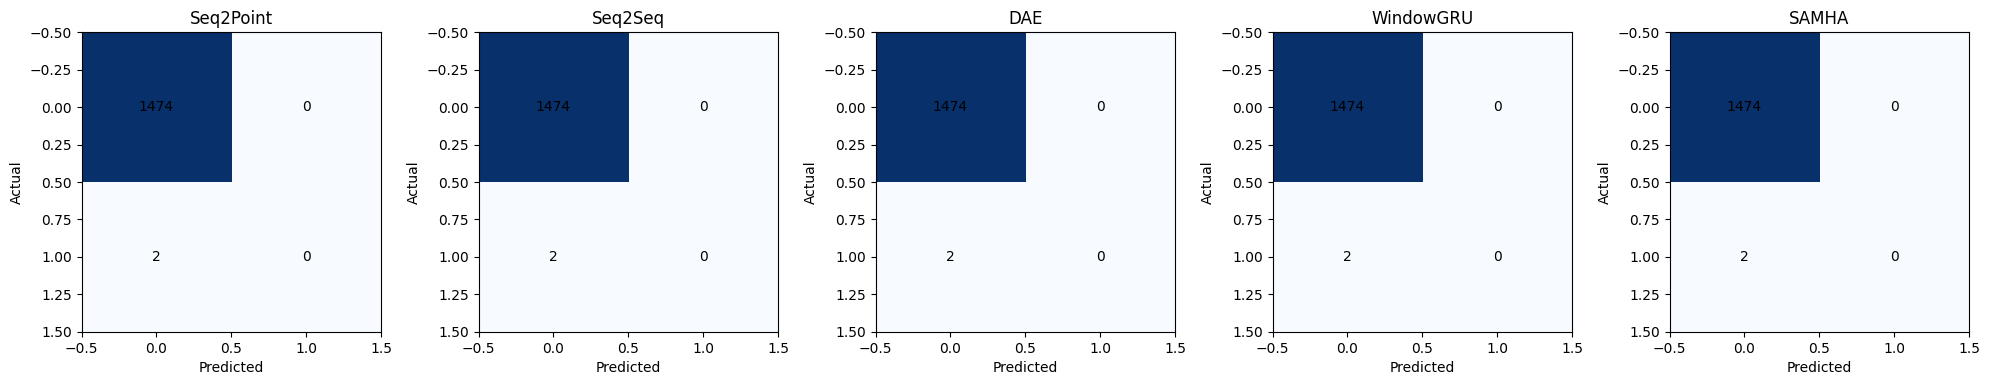

In [ ]:
# =========================================================
# COMPLETE IoT PIPELINE (FIXED & CSV-BASED)
# =========================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# ----------------------------
# 1. DATASET GENERATION
# ----------------------------
np.random.seed(42)

N = 1500
WINDOW = 24
FEATURES = 8
CSV_FILE = "sensors_iot.csv"

def generate_dataset():
    X, y = [], []

    for _ in range(N):
        temp = 25 + np.random.randn()*2
        hum = 60 + np.random.randn()*5
        mq = 150 + np.random.randn()*20
        pm25 = 40 + np.random.randn()*10
        pm10 = 70 + np.random.randn()*15
        co = 0.8 + np.random.randn()*0.1
        so2 = 8 + np.random.randn()*2
        no2 = 20 + np.random.randn()*5

        label = 1 if (pm25 > 55 and hum > 65 and mq > 170) else 0

        X.append([temp, hum, mq, pm25, pm10, co, so2, no2])
        y.append(label)

    df = pd.DataFrame(X, columns=[
        "temperature","humidity","MQ135",
        "PM25","PM10","CO","SO2","NO2"
    ])
    df["target"] = y
    return df

# Save dataset
df = generate_dataset()
df.to_csv(CSV_FILE, index=False)
print("Dataset saved to sensors_iot.csv")

# ----------------------------
# 2. DATASET CLASS (LOAD FROM CSV)
# ----------------------------
class IoTDataset(Dataset):
    def __init__(self, csv, window):
        df = pd.read_csv(csv)
        self.X = df.iloc[:, :-1].values
        self.y = df["target"].values
        self.window = window

    def __len__(self):
        return len(self.X) - self.window

    def __getitem__(self, idx):
        x = self.X[idx:idx+self.window]
        y = self.y[idx+self.window]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

dataset = IoTDataset(CSV_FILE, WINDOW)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

# ----------------------------
# 3. MODELS
# ----------------------------
class Seq2Point(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(8, 32, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x.permute(0,2,1))

class Seq2Seq(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(8, 64, batch_first=True)
        self.fc = nn.Linear(64,1)
    def forward(self, x):
        o,_ = self.lstm(x)
        return self.fc(o[:,-1,:])

class DAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Linear(8*WINDOW, 64)
        self.fc = nn.Linear(64,1)
    def forward(self, x):
        z = torch.relu(self.enc(x.view(x.size(0), -1)))
        return self.fc(z)

class WindowGRU(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(8, 64, batch_first=True)
        self.fc = nn.Linear(64,1)
    def forward(self, x):
        o,_ = self.gru(x)
        return self.fc(o[:,-1,:])

class SAMHA(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Conv1d(8, 64, 3, padding=1)
        self.gru = nn.GRU(64, 64, batch_first=True, bidirectional=True)
        self.att = nn.Linear(128,1)
        self.fc = nn.Linear(128,1)
    def forward(self, x):
        x = torch.relu(self.cnn(x.permute(0,2,1)))
        x = x.permute(0,2,1)
        h,_ = self.gru(x)
        w = torch.softmax(self.att(h), dim=1)
        return self.fc((h*w).sum(dim=1))

models = {
    "Seq2Point": Seq2Point(),
    "Seq2Seq": Seq2Seq(),
    "DAE": DAE(),
    "WindowGRU": WindowGRU(),
    "SAMHA": SAMHA()
}

# ----------------------------
# 4. TRAINING
# ----------------------------
def train(model):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.BCEWithLogitsLoss()
    model.train()
    for _ in range(8):
        for x,y in loader:
            opt.zero_grad()
            loss = loss_fn(model(x).squeeze(), y)
            loss.backward()
            opt.step()

# ----------------------------
# 5. EVALUATION (FIXED)
# ----------------------------
results = {}
confusions = {}

for name, model in models.items():
    train(model)
    model.eval()

    y_true, y_pred = [], []

    with torch.no_grad():
        for x,y in loader:
            logits = model(x).squeeze()
            probs = torch.sigmoid(logits)

            y_true.extend(y.numpy())
            y_pred.extend(probs.numpy())

    # ✅ FIX: convert list → numpy array
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    y_pred_cls = (y_pred > 0.5).astype(int)

    cm = confusion_matrix(y_true, y_pred_cls)
    tn, fp, fn, tp = cm.ravel()

    results[name] = {
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "Accuracy": accuracy_score(y_true, y_pred_cls),
        "Precision": precision_score(y_true, y_pred_cls),
        "Recall": recall_score(y_true, y_pred_cls),
        "F1": f1_score(y_true, y_pred_cls)
    }

    confusions[name] = cm

# ----------------------------
# 6. RESULTS
# ----------------------------
df_results = pd.DataFrame(results).T
print("\nFINAL METRICS\n")
print(df_results)

# ----------------------------
# 7. CONFUSION MATRICES
# ----------------------------
fig, axes = plt.subplots(1, 5, figsize=(20,4))
for ax, (name, cm) in zip(axes, confusions.items()):
    ax.imshow(cm, cmap="Blues")
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i,j], ha="center", va="center")
plt.tight_layout()
plt.show()


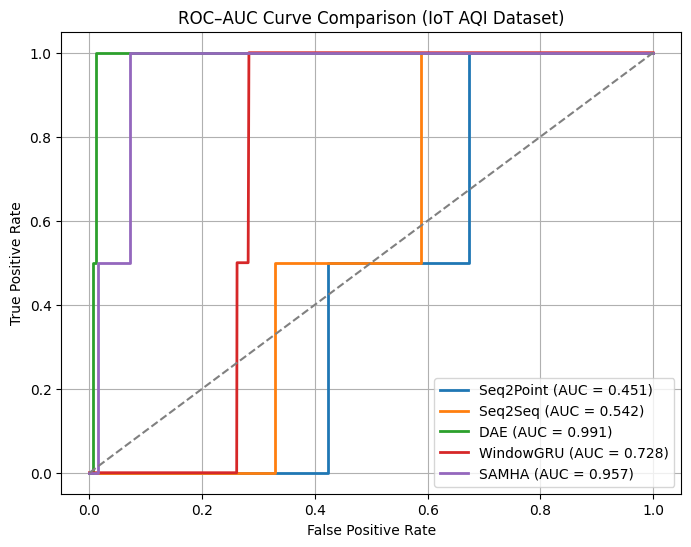

In [ ]:
 from sklearn.metrics import roc_curve, auc

# ----------------------------
# ROC – AUC CURVES
# ----------------------------
plt.figure(figsize=(8,6))

for name, model in models.items():
    y_true_all, y_prob_all = [], []

    with torch.no_grad():
        for x,y in loader:
            logits = model(x).squeeze()
            probs = torch.sigmoid(logits)

            y_true_all.extend(y.numpy())
            y_prob_all.extend(probs.numpy())

    # Convert to numpy arrays
    y_true_all = np.array(y_true_all)
    y_prob_all = np.array(y_prob_all)

    # ROC curve
    fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")

# Random guess line
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC–AUC Curve Comparison (IoT AQI Dataset)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()



In [ ]:
from sklearn.model_selection import train_test_split

df = pd.read_csv("sensors_iot.csv")

X = df.drop(columns=["target"]).values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

class IoTDatasetFromArray(Dataset):
    def __init__(self, X, y, window):
        self.X = X
        self.y = y
        self.window = window

    def __len__(self):
        return len(self.X) - self.window

    def __getitem__(self, idx):
        return (
            torch.tensor(self.X[idx:idx+self.window], dtype=torch.float32),
            torch.tensor(self.y[idx+self.window], dtype=torch.float32)
        )



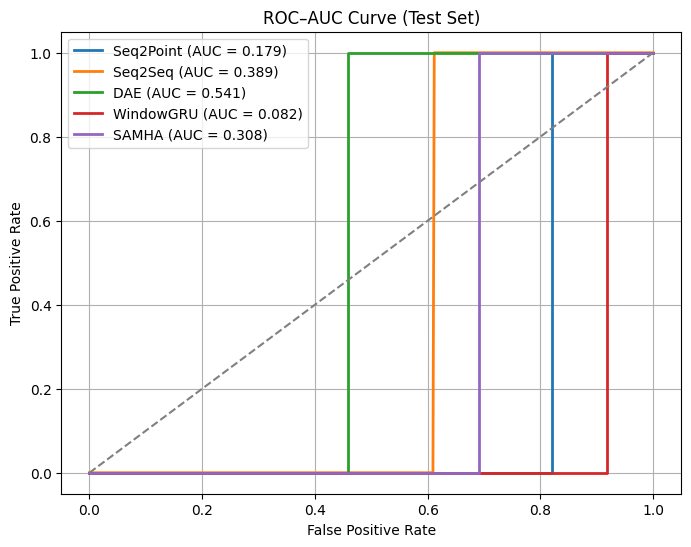

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for name, model in models.items():
    test_dataset = IoTDatasetFromArray(X_test, y_test, WINDOW)
    test_loader = DataLoader(test_dataset, batch_size=64)

    y_true_all, y_prob_all = [], []

    model.eval()
    with torch.no_grad():
        for x,y in test_loader:
            logits = model(x).squeeze()
            probs = torch.sigmoid(logits)

            y_true_all.extend(y.numpy())
            y_prob_all.extend(probs.numpy())

    y_true_all = np.array(y_true_all)
    y_prob_all = np.array(y_prob_all)

    fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC–AUC Curve (Test Set)")
plt.legend()
plt.grid(True)
plt.show()
